### Feature Selection, and Findings: 
- Utilizing unit, and sector related features was more effective than unit, and district.
- Most of the numerical features did not show significant co-linearity.
    - Excluding longitude, latitude, and headcount, which were correlated with easting, northing, and households respectively. Thus, they were dropped.
- Almost all of the numerical features were heavily skewed. However, most of these values seemed reasonable, thus no outlier handling was used. However, a robust scaler was utilized to minimize the impact of these skewed distributions.
- Tested utilizing a "distance to london" feature. However, it did not improve the performance of the model significantly, and it had high co-linearity with easting.
- Only "soilType" was utilized from the categorical features since the other features had a significant number of unique values.
- Tested utilizing XGBoost categorical feature encoding for the other features. However, it did not have any significant impact on the model.

### Model Selection:
- XGBoost was selected after testing a few different models primarily due to:
    - Ability to utilize validation set during training
    - Relatively short training time
    - Relatively balanced prediction (not over-fitted).
- Applying a log transformer to the median house price (target) resulted in the most significant improvement since it managed to deal with the significant outliers associated with the house prices.
- A simple linear regression model was tested initially. However, even with the log transformation applied, the performance was poor.
- A RandomForestRegressor was tested as well. However, it was over-fitting significantly (observed by looking at training curve).
- England median house price value is filled where the postcodes do not have the required features from the preprocessed dataset.

### Areas of Improvement:
- Explore more feature engineering options.
- Explore using an ensemble model combining two XGBoost regression models trained with the sector, and district data separately.
- Explore hyperparameter optimization.

In [69]:
import sys
sys.path.append('..') # Add parent directory to path to always find flood_tool
                      # This is not best practice, but it works for this example

import flood_tool as ft

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn import set_config
set_config(transform_output = "pandas")

# Reading datasets
district_data = ft.utils.read_csv_from_resources('preprocessed_data/district_imputed.csv')
unit_data = ft.utils.read_csv_from_resources('preprocessed_data/postcodes_impute_postcode_method.csv')
sector_data = ft.utils.read_csv_from_resources('preprocessed_data/sector_preprocessed.csv')


In [70]:
# Plotting functions for analysis and model evaluation
def plot_prediction_results(y_true, y_pred):
    plt.figure(figsize=(10, 10))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.title('XGBoost Model Actual vs Predicted Median House Price', fontsize=16)
    plt.xlabel('Actual Median House Price (Million GBP)', fontsize=14)
    plt.ylabel('Predicted Median House Price (Million GBP)', fontsize=14)
    plt.xlim(y_true.quantile(0.05), y_true.quantile(0.95))
    plt.ylim(y_true.quantile(0.05), y_true.quantile(0.95))
    plt.grid(True)
    plt.show()
    return None


def plot_learning_curve(train_scores, val_scores, score_name='Score'):
    plt.figure(figsize=(15, 10))
    plt.plot(train_scores, label='Training Score', color='blue')
    plt.plot(val_scores, label='Validation Score', color='orange')
    plt.title('Learning Curve', fontsize=16)
    plt.xlabel('Iterations')
    plt.ylabel(score_name)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()
    # Can added mean and std values of the scores later
    return None


def colinarity_heatmap(df):
    corr = df.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='seismic', cbar=True,
                xticklabels=df.corr().columns, yticklabels=df.corr().columns,
                vmin=-1, vmax=1)
    plt.title('Correlation Heatmap', fontsize=16)
    plt.show()
    return corr

In [71]:
# Merging the two datasets by District
merge_district = ft.unit_district_merge(unit_data, district_data)

display(merge_district.head())
print(merge_district.nunique())
print(merge_district.shape)
print(merge_district.isna().sum().sum())

,postcode,postcodeDistrict,postcodeSector,easting,northing,longitude,latitude,soilType,elevation,nearestWatercourse,...,catsPerHousehold,dogsPerHousehold,pre_1900,1900_1929,1930_1945,1945_1964,1965_1982,1983_1999,2000_present,unknown
0,BA10 0AD,BA10,BA10 0,368289,134886,-2.454381,51.112382,Unsurveyed/Urban,70,Combe Brook,...,0.771927,0.885263,0.28368,0.06661,0.044638,0.107629,0.111352,0.21416,0.112443,0.047177
1,BA10 0AG,BA10,BA10 0,368240,134813,-2.455075,51.111723,Unsurveyed/Urban,60,Combe Brook,...,0.771927,0.885263,0.28368,0.06661,0.044638,0.107629,0.111352,0.21416,0.112443,0.047177
2,BA10 0AZ,BA10,BA10 0,367936,134742,-2.459411,51.111068,Unsurveyed/Urban,60,Combe Brook,...,0.771927,0.885263,0.28368,0.06661,0.044638,0.107629,0.111352,0.21416,0.112443,0.047177
3,BA10 0BB,BA10,BA10 0,367980,134623,-2.458772,51.110000,Unsurveyed/Urban,60,Combe Brook,...,0.771927,0.885263,0.28368,0.06661,0.044638,0.107629,0.111352,0.21416,0.112443,0.047177
4,BA10 0BH,BA10,BA10 0,367942,134697,-2.459321,51.110663,Unsurveyed/Urban,60,Combe Brook,...,0.771927,0.885263,0.28368,0.06661,0.044638,0.107629,0.111352,0.21416,0.112443,0.047177


postcode                 80000
postcodeDistrict           420
postcodeSector            1296
easting                  68630
northing                 55058
longitude                80000
latitude                 80000
soilType                    10
elevation                   45
nearestWatercourse         943
distanceToWatercourse      872
localAuthority              89
riskLabel                    7
medianPrice              12136
historicallyFlooded          2
catsPerHousehold           398
dogsPerHousehold           398
pre_1900                   417
1900_1929                  409
1930_1945                  406
1945_1964                  411
1965_1982                  408
1983_1999                  409
2000_present               410
unknown                    401
dtype: int64
(80000, 25)
0


In [72]:
# Merging the two datasets by Sector
merge_sector = ft.unit_sector_merge(unit_data, sector_data)

display(merge_sector.head())
print(merge_sector.nunique())
print(merge_sector.shape)
print(merge_sector.isna().sum().sum())

,postcode,postcodeDistrict,postcodeSector,easting,northing,longitude,latitude,soilType,elevation,nearestWatercourse,distanceToWatercourse,localAuthority,riskLabel,medianPrice,historicallyFlooded,households,numberOfPostcodeUnits,headcount,postcodeDistrict_sector
0,BA10 0AD,BA10,BA10 0,368289,134886,-2.454381,51.112382,Unsurveyed/Urban,70,Combe Brook,770.0,South Somerset,3,520900.0,0,1474.0,200.0,3674.0,BA10
1,BA10 0AG,BA10,BA10 0,368240,134813,-2.455075,51.111723,Unsurveyed/Urban,60,Combe Brook,840.0,South Somerset,3,513200.0,0,1474.0,200.0,3674.0,BA10
2,BA10 0AZ,BA10,BA10 0,367936,134742,-2.459411,51.111068,Unsurveyed/Urban,60,Combe Brook,970.0,South Somerset,3,850600.0,0,1474.0,200.0,3674.0,BA10
3,BA10 0BB,BA10,BA10 0,367980,134623,-2.458772,51.110000,Unsurveyed/Urban,60,Combe Brook,1070.0,South Somerset,6,413100.0,1,1474.0,200.0,3674.0,BA10
4,BA10 0BH,BA10,BA10 0,367942,134697,-2.459321,51.110663,Unsurveyed/Urban,60,Combe Brook,1010.0,South Somerset,3,525500.0,0,1474.0,200.0,3674.0,BA10


postcode                   79749
postcodeDistrict             416
postcodeSector              1288
easting                    68468
northing                   54971
longitude                  79749
latitude                   79749
soilType                      10
elevation                     45
nearestWatercourse           942
distanceToWatercourse        872
localAuthority                89
riskLabel                      7
medianPrice                12022
historicallyFlooded            2
households                  1138
numberOfPostcodeUnits        321
headcount                   1234
postcodeDistrict_sector      416
dtype: int64
(79749, 19)
0


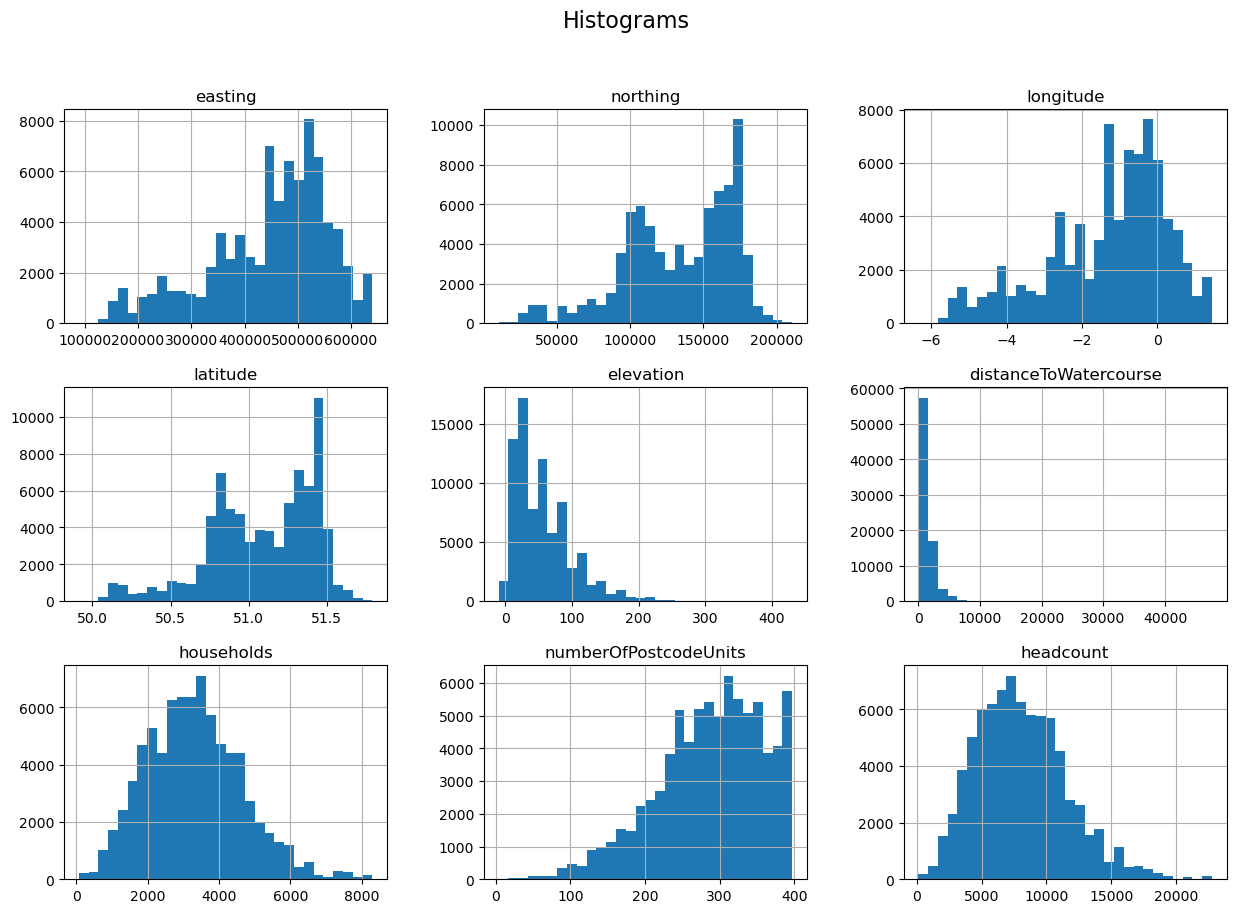

In [73]:
X_eda = merge_sector.drop(columns=['riskLabel', 'medianPrice', 'historicallyFlooded', ])

X_eda.hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms', fontsize=16)
plt.show()

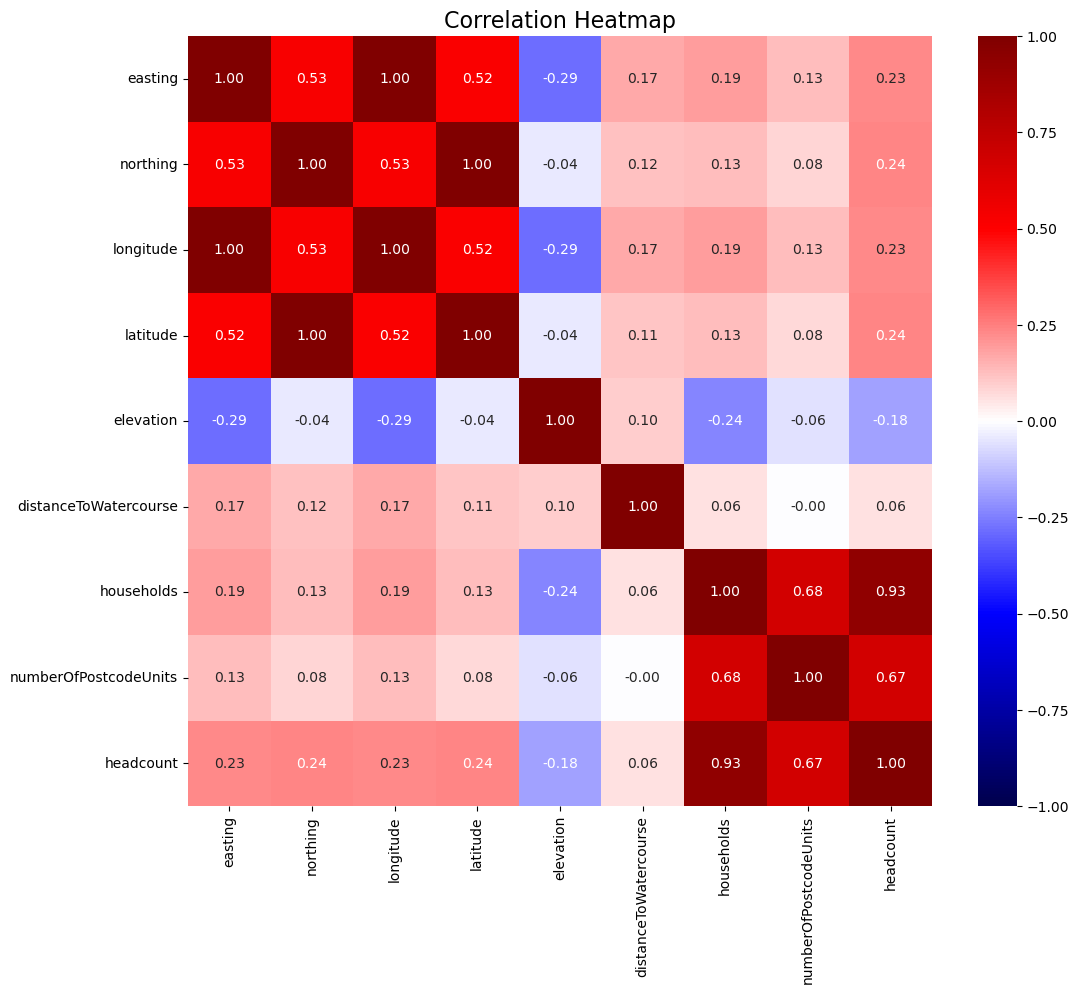

In [74]:
corr = colinarity_heatmap(X_eda.select_dtypes(include=[np.number]))

In [75]:
# Defining features and target for both datasets
X_sector = merge_sector.drop(columns=['medianPrice'])
y_sector = merge_sector['medianPrice']
X_district = merge_district.drop(columns=['medianPrice'])
y_district = merge_district['medianPrice']

proc_pipe_sector = ft.price_proc.house_proc_pipeline(merge_with='sector')
proc_pipe_district = ft.price_proc.house_proc_pipeline(merge_with='district')

# Train-test split and preprocessing for both datasets
X_sec_train, X_sec_test, y_sec_train, y_sec_test = train_test_split(X_sector, y_sector, test_size=0.1, random_state=42)
X_sec_train, X_sec_val, y_sec_train, y_sec_val = train_test_split(X_sec_train, y_sec_train, test_size=0.1, random_state=42)
X_sec_train = proc_pipe_sector.fit_transform(X_sec_train)
X_sec_val = proc_pipe_sector.transform(X_sec_val)
X_sec_test = proc_pipe_sector.transform(X_sec_test)

X_dist_train, X_dist_test, y_dist_train, y_dist_test = train_test_split(X_district, y_district, test_size=0.1, random_state=42)
X_dist_train, X_dist_val, y_dist_train, y_dist_val = train_test_split(X_dist_train, y_dist_train, test_size=0.1, random_state=42)
X_dist_train = proc_pipe_district.fit_transform(X_dist_train)
X_dist_val = proc_pipe_district.transform(X_dist_val)
X_dist_test = proc_pipe_district.transform(X_dist_test)

In [76]:
xgb_reg_sector = ft.models.HousePricesXGBRegressor()
xgb_reg_sector.fit(X_sec_train, y_sec_train, eval_set=[(X_sec_train, y_sec_train),(X_sec_val, y_sec_val)], verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,15
,enable_categorical,False
,eval_metric,'rmse'


In [77]:
xgb_reg_district = ft.models.HousePricesXGBRegressor()
xgb_reg_district.fit(X_dist_train, y_dist_train, eval_set=[(X_dist_train, y_dist_train),(X_dist_val, y_dist_val)], verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,15
,enable_categorical,False
,eval_metric,'rmse'


In [78]:
y_pred_sector = xgb_reg_sector.predict(X_sec_test)
y_pred_district = xgb_reg_district.predict(X_dist_test)

XGB Test RMSE: 506771.2664514356
XGB Test R2: 0.21639167730449282
XGB Test MAE: 103626.3377096395


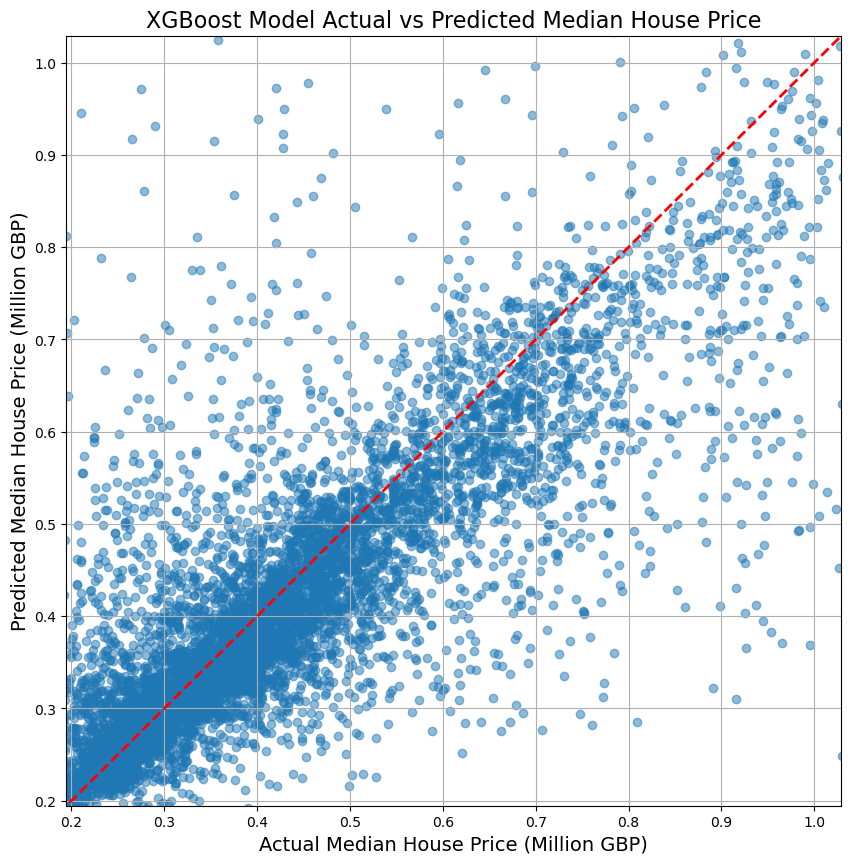

In [79]:
rmse_sector = root_mean_squared_error(y_sec_test, y_pred_sector)
r2_sector = r2_score(y_sec_test, y_pred_sector)
mae_sector = mean_absolute_error(y_sec_test, y_pred_sector)

print(f"XGB Test RMSE: {rmse_sector}")
print(f"XGB Test R2: {r2_sector}")
print(f"XGB Test MAE: {mae_sector}")

plot_prediction_results(y_sec_test/1e6, y_pred_sector/1e6)

XGB Test RMSE: 414043.22926266503
XGB Test R2: 0.26301759061777286
XGB Test MAE: 115684.08651953125


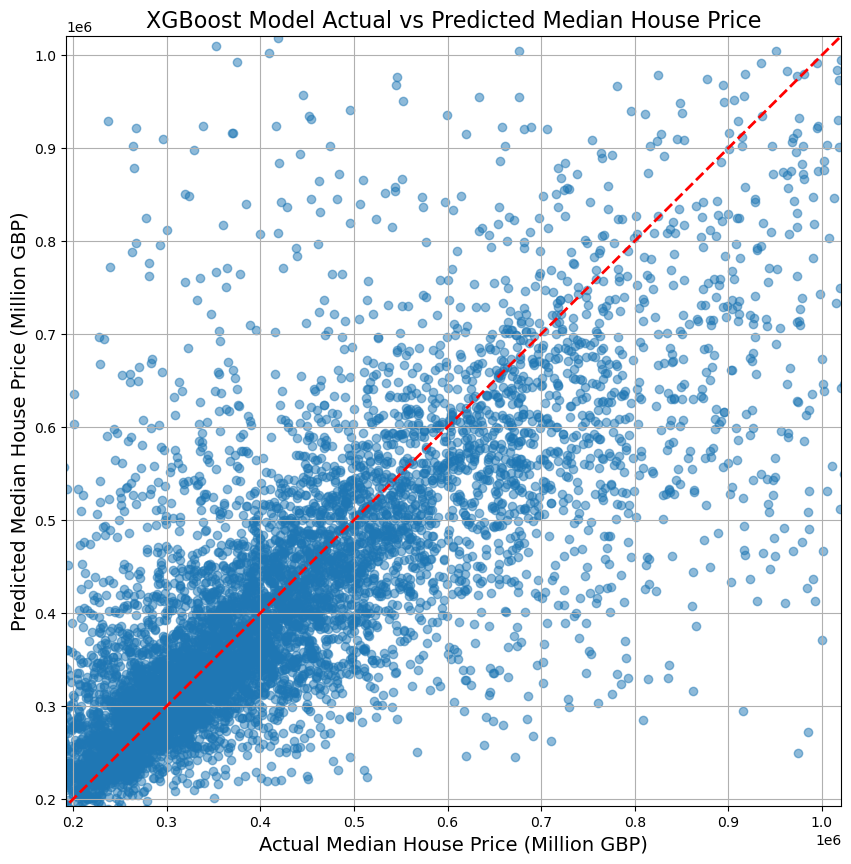

In [80]:
rmse_district = root_mean_squared_error(y_dist_test, y_pred_district)
r2_district = r2_score(y_dist_test, y_pred_district)
mae_district = mean_absolute_error(y_dist_test, y_pred_district)

print(f"XGB Test RMSE: {rmse_district}")
print(f"XGB Test R2: {r2_district}")
print(f"XGB Test MAE: {mae_district}")
plot_prediction_results(y_dist_test, y_pred_district)

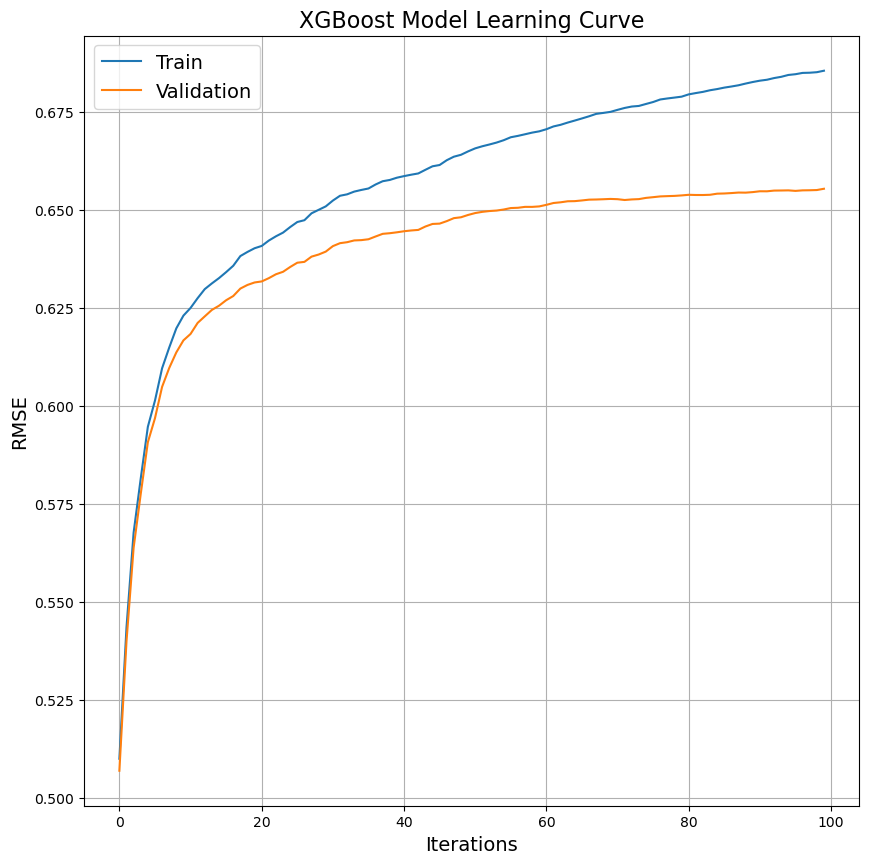

In [81]:
results_sector = xgb_reg_sector.evals_result()

fig, ax = plt.subplots(1,1, figsize=(10,10))

ax.plot(1-np.array(results_sector['validation_0']['rmse']), label='Train')
ax.plot(1-np.array(results_sector['validation_1']['rmse']), label='Validation')
ax.set_title('XGBoost Model Learning Curve', fontsize=16)
ax.set_xlabel('Iterations', fontsize=14)
ax.set_ylabel('RMSE', fontsize=14)
ax.grid(True)
ax.legend(fontsize=14)
plt.show()

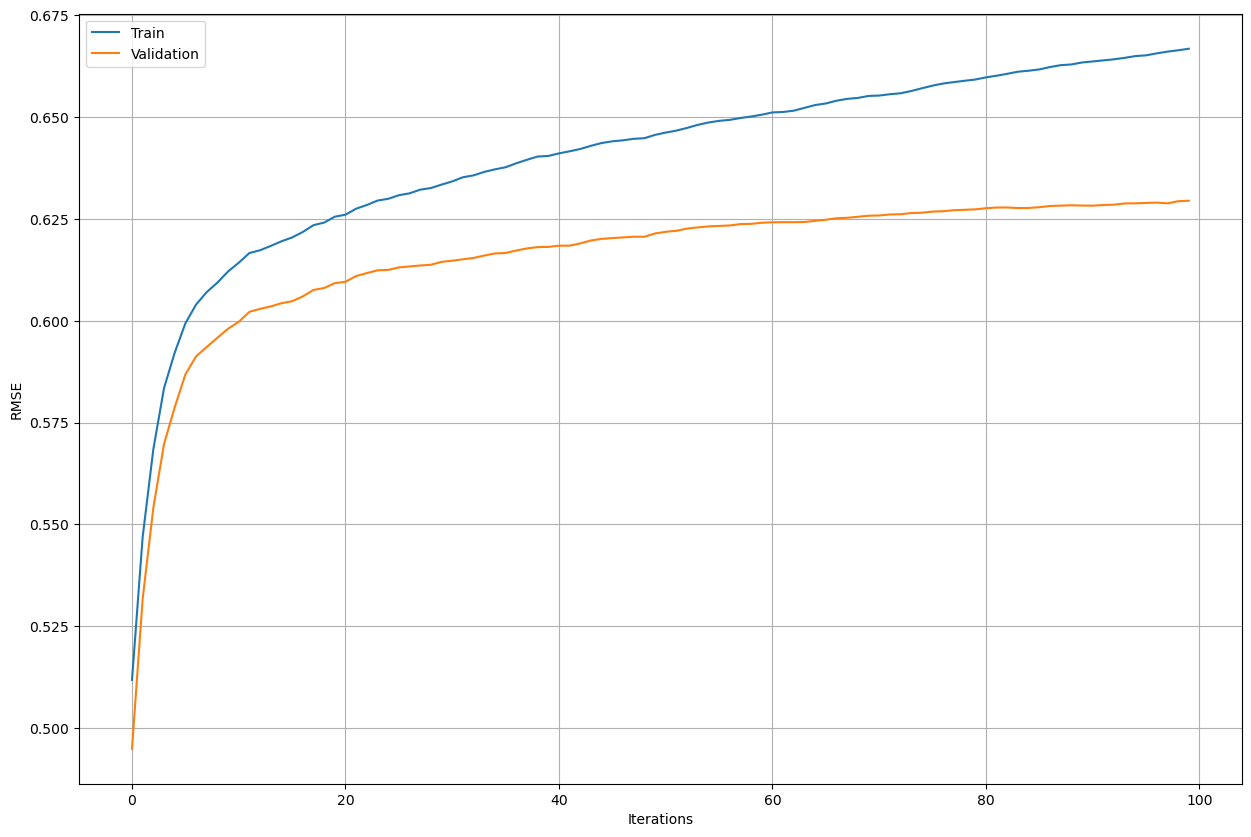

In [82]:
results_district = xgb_reg_district.evals_result()

fig, ax = plt.subplots(1,1, figsize=(15,10))

ax.plot(1-np.array(results_district['validation_0']['rmse']), label='Train')
ax.plot(1-np.array(results_district['validation_1']['rmse']), label='Validation')
ax.set_xlabel('Iterations')
ax.set_ylabel('RMSE')
ax.grid(True)
ax.legend()
plt.show()

In [83]:
# Unsure how to stack these two models properly, need to research more
"""
from sklearn.ensemble import StackingRegressor

estimators = [
    ('xgb_sector', xgb_reg_sector),
    ('xgb_district', xgb_reg_district)
]

xgb_stack = StackingRegressor(estimators=estimators, 
                              final_estimator=xgb.XGBRegressor(early_stopping_rounds=15, eval_metric='rmse'))

"""

"\nfrom sklearn.ensemble import StackingRegressor\n\nestimators = [\n    ('xgb_sector', xgb_reg_sector),\n    ('xgb_district', xgb_reg_district)\n]\n\nxgb_stack = StackingRegressor(estimators=estimators, \n                              final_estimator=xgb.XGBRegressor(early_stopping_rounds=15, eval_metric='rmse'))\n\n"

In [84]:
"""
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42, criterion='squared_error')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Test MSE: {mse_rf}")
print(f"Random Forest Test R2: {r2_rf}")

plot_prediction_results(y_test, y_pred_rf)
"""

'\nfrom sklearn.ensemble import RandomForestRegressor\n\nrf = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42, criterion=\'squared_error\')\nrf.fit(X_train, y_train)\ny_pred_rf = rf.predict(X_test)\n\nmse_rf = mean_squared_error(y_test, y_pred_rf)\nr2_rf = r2_score(y_test, y_pred_rf)\n\nprint(f"Random Forest Test MSE: {mse_rf}")\nprint(f"Random Forest Test R2: {r2_rf}")\n\nplot_prediction_results(y_test, y_pred_rf)\n'

In [85]:
#train_sizes, train_scores, test_scores  = learning_curve(rf, X_train, y_train, cv=5, scoring='r2', random_state=42)

#print(f'Mean training scores: {np.mean(train_scores, axis=1)} and mean validation scores: {np.mean(test_scores, axis=1)}')
#plot_learning_curve(np.mean(train_scores, axis=1), np.mean(test_scores, axis=1), score_name='r2 Score')